In [23]:
import numpy as np
import pandas as pd
import seaborn as sns

In [24]:
df=pd.read_csv("iris.data.csv")

In [25]:
df.head()

,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


In [29]:
df.columns[4]

'Iris-setosa'

In [30]:
df.columns = ['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm','Species']

In [31]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


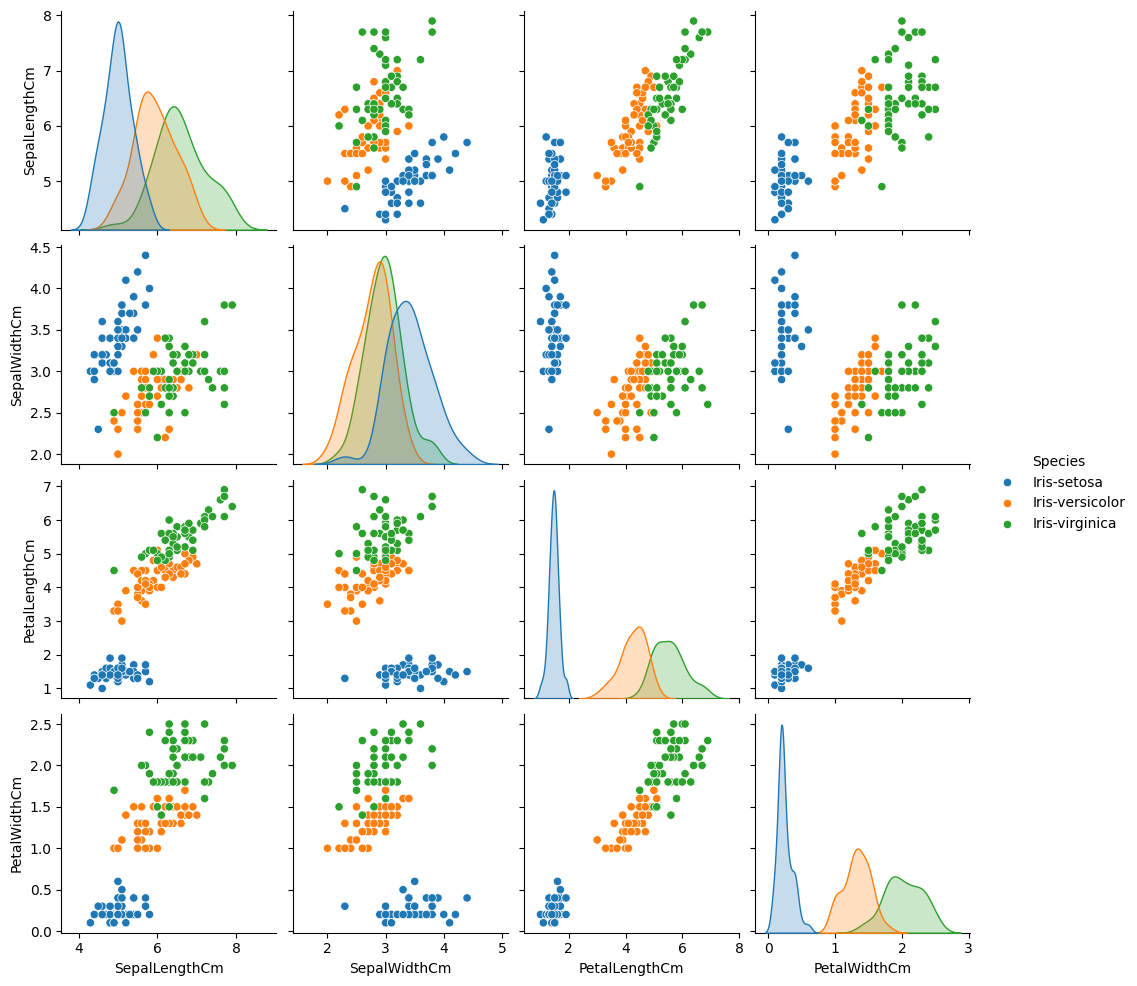

In [35]:
sns.pairplot(df,hue='Species')  # The data is split into subgroups, and each group gets a different color automatically.

In [43]:
new_df=df[df['Species'] != 'Iris-setosa'][['SepalLengthCm','SepalWidthCm','Species']]

In [44]:
new_df.head()

,SepalLengthCm,SepalWidthCm,Species
49,7.0,3.2,Iris-versicolor
50,6.4,3.2,Iris-versicolor
51,6.9,3.1,Iris-versicolor
52,5.5,2.3,Iris-versicolor
53,6.5,2.8,Iris-versicolor


In [47]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [48]:
X

,SepalLengthCm,SepalWidthCm
0,4.9,3.0
1,4.7,3.2
2,4.6,3.1
3,5.0,3.6
4,5.4,3.9
...,...,...
144,6.7,3.0
145,6.3,2.5
146,6.5,3.0
147,6.2,3.4


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [50]:
clf1 = LogisticRegression()
clf2 = RandomForestClassifier()
clf3 = KNeighborsClassifier()

In [51]:
estimators = [('lr',clf1),('rf',clf2),('knn',clf3)]

In [52]:
for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))

lr 0.81
rf 0.73
knn 0.76


In [53]:
from sklearn.ensemble import VotingClassifier

## Hard Voting

In [54]:
vc = VotingClassifier(estimators=estimators,voting='hard')
x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.77


## Soft Voting

In [60]:
vc1= VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc1,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.76


## Weighted voting

In [61]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            vc = VotingClassifier(estimators=estimators,voting='soft',weights=[i,j,k])
            x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
            print("for i={},j={},k={}".format(i,j,k),np.round(np.mean(x),2))

for i=1,j=1,k=1 0.75
for i=1,j=1,k=2 0.77
for i=1,j=1,k=3 0.76
for i=1,j=2,k=1 0.75
for i=1,j=2,k=2 0.76
for i=1,j=2,k=3 0.75
for i=1,j=3,k=1 0.74
for i=1,j=3,k=2 0.75
for i=1,j=3,k=3 0.76
for i=2,j=1,k=1 0.78
for i=2,j=1,k=2 0.76
for i=2,j=1,k=3 0.77
for i=2,j=2,k=1 0.77
for i=2,j=2,k=2 0.76
for i=2,j=2,k=3 0.76
for i=2,j=3,k=1 0.75
for i=2,j=3,k=2 0.77
for i=2,j=3,k=3 0.77
for i=3,j=1,k=1 0.8
for i=3,j=1,k=2 0.78
for i=3,j=1,k=3 0.78
for i=3,j=2,k=1 0.78
for i=3,j=2,k=2 0.77
for i=3,j=2,k=3 0.76
for i=3,j=3,k=1 0.77
for i=3,j=3,k=2 0.76
for i=3,j=3,k=3 0.77
